# Home Credit — Exploratory Data Analysis

Portfolio-level analysis of the Home Credit Default Risk application book, covering
dataset structure, feature categorization, data quality, and the business insights
that shape the modelling decisions taken in `src/ml/`.

**This notebook is a presentation layer, not an implementation.** Every calculation
lives in the importable module `notebooks/eda.py`, which the Streamlit UI and the
README also read from. That keeps one source of truth: a number shown here is the
same number the app shows, because it came from the same function.

Run order: top to bottom. Runs against the committed synthetic fixtures by default
(`DATA_MODE=sample`), or against the real Kaggle CSVs with `DATA_MODE=real` — no
code changes either way.

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Allow `import src...` / `import notebooks...` when Jupyter starts in notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display

from notebooks import eda
from src.data.loader import build_dataset
from src.utils.config import settings

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print(f"Data mode : {settings.data_mode.value}")
print(f"Reading   : {settings.active_data_dir}")

Data mode : sample
Reading   : /Users/neeeha_k/credit_risk_platform/data/sample


In [2]:
# Application table LEFT JOINed with applicant-level bureau aggregates.
df = build_dataset("train")
df.shape

2026-09-06 08:16:06 | INFO     | src.data.loader | Read application_train.csv -> 4,000 rows x 122 cols


2026-09-06 08:16:06 | INFO     | src.data.loader | Read bureau.csv -> 11,963 rows x 17 cols


2026-09-06 08:16:06 | INFO     | src.data.loader | Aggregated bureau: 3,904 applicants x 24 features


2026-09-06 08:16:06 | INFO     | src.data.loader | Joined bureau onto 4,000 applications: 3,259 matched (81.5%), 741 without history


(4000, 147)

## 1. Dataset summary

Shape, memory footprint, and — the number that drives every later modelling
decision — the target distribution.

In [3]:
summary = eda.dataset_overview(df)
pd.Series(summary, name="value").to_frame()

2026-09-06 08:16:06 | INFO     | notebooks.eda | Dataset: 4,000 rows x 147 cols | default rate 8.62% | imbalance 10.6:1


,value
n_rows,4000.0000
n_columns,147.0000
memory_mb,7.7400
n_bureau_features,25.0000
columns_with_missing,48.0000
overall_missing_pct,6.8600
n_defaults,345.0000
default_rate,0.0862
imbalance_ratio,10.6000
n_applicants,4000.0000


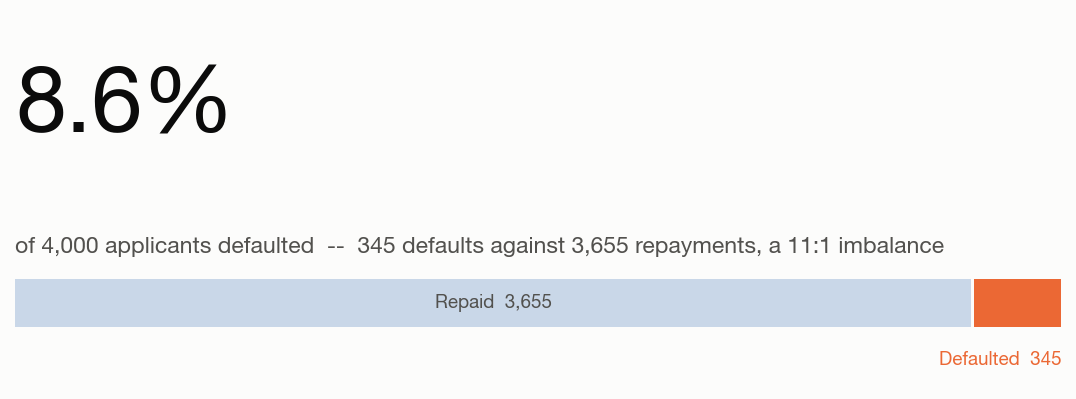

Only 8.6% of applicants default, a 11:1 imbalance. Accuracy is meaningless here -- a model predicting 'everyone repays' scores 91.4%. This is why the project leads with PR-AUC, weights the positive class rather than oversampling it, and tunes decision thresholds instead of using 0.5.


In [4]:
insight = eda.insight_class_imbalance(df)
display(Image(str(insight.figure_path)))
print(insight.takeaway)

### Why the imbalance dominates the design

At roughly a 1-in-12 default rate, three consequences follow, and each is acted on
later in the pipeline:

| Consequence | Where it is handled |
|---|---|
| Accuracy is uninformative — "everyone repays" scores >91% | `evaluate.py` leads with **PR-AUC**, not accuracy |
| The minority class needs weighting, not synthetic duplication | `train.py` uses `scale_pos_weight` / `class_weight`; **no SMOTE**, which distorts calibration |
| A 0.5 cut-off would approve nearly everyone | `train.py` **tunes** the band thresholds on out-of-fold predictions |

## 2. Feature categorization

Two independent groupings, answering different questions. Storage type decides how a
column is *encoded*; business domain decides who *owns* it and how a finding about it
gets acted on.

In [5]:
catalog = eda.feature_catalog(df)
catalog["type_bucket"].value_counts().to_frame("columns")

2026-09-06 08:16:06 | INFO     | notebooks.eda | Feature catalog: {'numeric': 88, 'binary': 36, 'categorical': 16, 'date_like': 5, 'identifier': 1, 'target': 1}


,columns
type_bucket,
numeric,88
binary,36
categorical,16
date_like,5
identifier,1
target,1


In [6]:
catalog["domain"].value_counts().to_frame("columns")

,columns
domain,
property,47
demographics,31
credit_history,31
documents,20
other,6
application_process,4
financials,4
external_scores,3
identifier,1


2026-09-06 08:16:06 | INFO     | notebooks.eda | Feature catalog: {'numeric': 88, 'binary': 36, 'categorical': 16, 'date_like': 5, 'identifier': 1, 'target': 1}


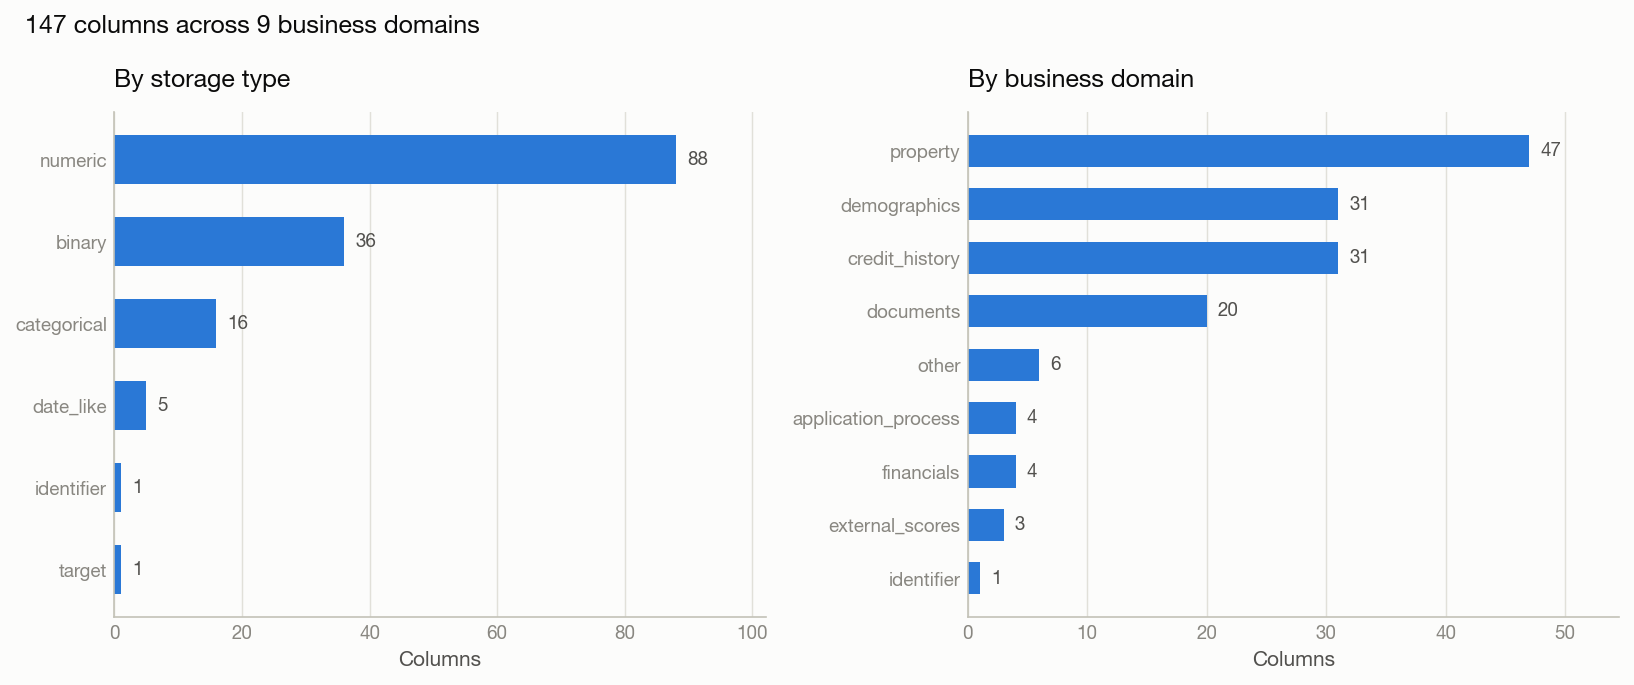

The 147 columns split into 88 numeric, 16 categorical, 36 binary and 5 date-like fields. By domain, the largest block is property (47 columns). Property attributes and document flags dominate by count but carry little signal, while the small external-score and financial blocks carry most of it -- so feature count is a poor guide to feature value.


In [7]:
landscape = eda.insight_feature_landscape(df)
display(Image(str(landscape.figure_path)))
print(landscape.takeaway)

In [8]:
# The engineered ratio and external-score features carry most of the signal
# despite being a small fraction of the column count.
catalog[catalog["domain"].isin(["external_scores", "financials"])]

,column,type_bucket,domain,pct_missing,n_unique
7,AMT_INCOME_TOTAL,numeric,financials,0.00,148
8,AMT_CREDIT,numeric,financials,0.00,567
9,AMT_GOODS_PRICE,numeric,financials,0.72,534
10,AMT_ANNUITY,numeric,financials,0.32,338
41,EXT_SOURCE_1,numeric,external_scores,56.82,1706
42,EXT_SOURCE_2,numeric,external_scores,0.22,3934
43,EXT_SOURCE_3,numeric,external_scores,18.60,3219


## 3. Data quality and missing values

Every defect below is *acted on* in `src/data/preprocessor.py` — this section is what
justifies that code existing.

In [9]:
missing = eda.missing_value_report(df)
missing.head(20)

,column,dtype,n_missing,pct_missing,n_unique
0,OWN_CAR_AGE,float64,3523,88.08,35
1,FONDKAPREMONT_MODE,object,2730,68.25,4
2,EXT_SOURCE_1,float64,2273,56.82,1706
3,WALLSMATERIAL_MODE,object,2077,51.92,7
4,BUREAU_MAX_OVERDUE_MEAN,float64,2074,51.85,1842
5,HOUSETYPE_MODE,object,2013,50.32,3
6,EMERGENCYSTATE_MODE,object,1942,48.55,2
7,TOTALAREA_MODE,float64,1941,48.52,1766
8,OCCUPATION_TYPE,object,1300,32.50,18
9,EXT_SOURCE_3,float64,744,18.60,3219


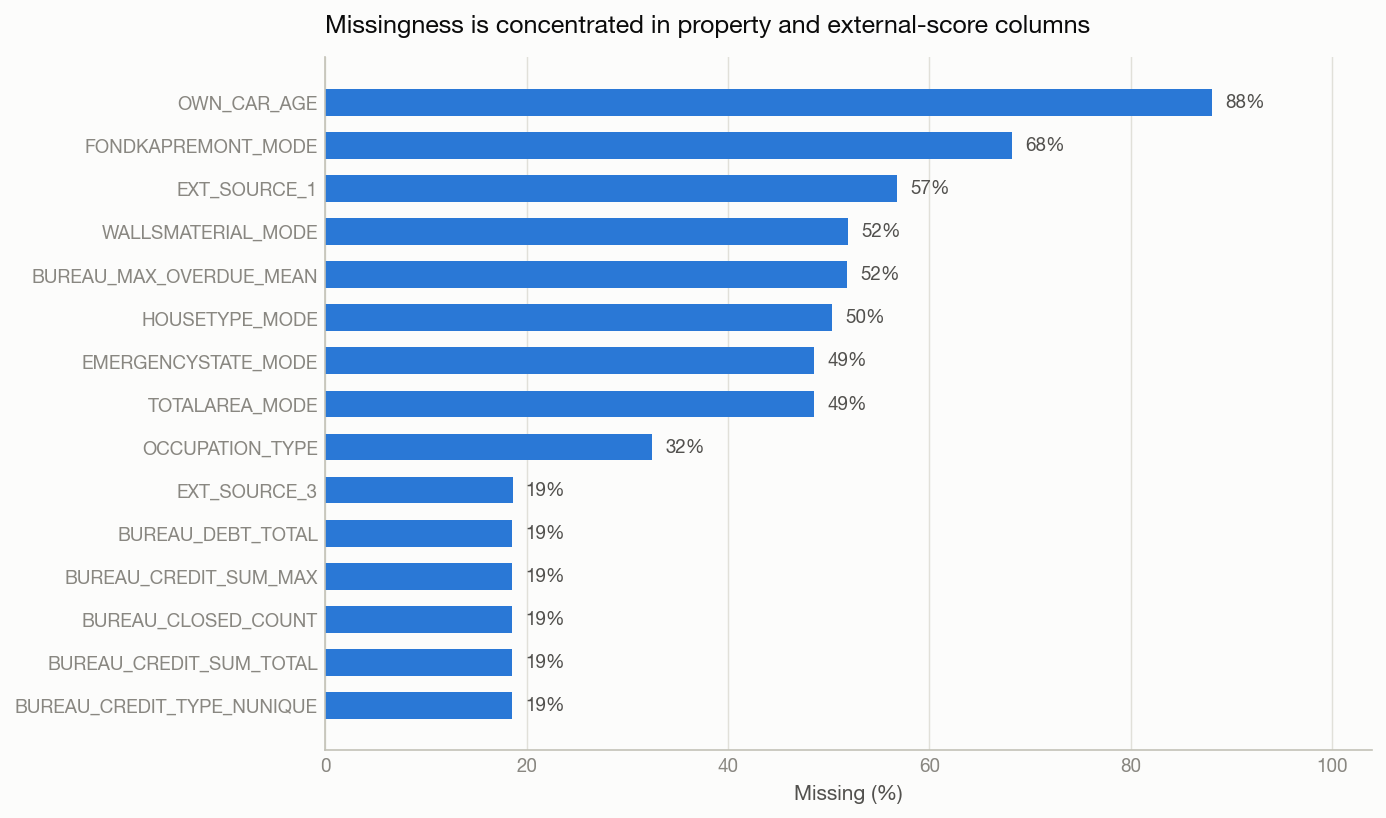

6 columns are more than half empty, led by OWN_CAR_AGE at 88%. Most are optional property attributes. Critically, EXT_SOURCE_1 -- one of the strongest predictors -- is missing for the majority of applicants, which is exactly why the model uses the mean/min/count of the three external scores rather than any single one. Missingness is kept, not imputed away: for tree models an absent value is a usable branch, and a thin file is real risk information.


In [10]:
quality = eda.insight_missing_data(df)
display(Image(str(quality.figure_path)))
print(quality.takeaway)

### Concrete defects and their treatment

In [11]:
findings = eda.data_quality_findings(df)
pd.DataFrame(findings)[["severity", "issue", "n_affected", "pct_affected", "treatment"]]

2026-09-06 08:16:06 | INFO     | notebooks.eda | Data quality: 5 findings


,severity,issue,n_affected,pct_affected,treatment
0,high,DAYS_EMPLOYED sentinel value 365243,714,17.85,Nulled and replaced with an explicit DAYS_EMPL...
1,low,CODE_GENDER = 'XNA',6,0.15,Mapped to null rather than treated as a third ...
2,medium,Columns more than 50% missing,6,4.08,"Retained un-imputed for the tree models, which..."
3,medium,Extreme income outliers,36,0.90,Left in place -- tree models are rank-based an...
4,medium,Applicants with no external credit history,741,18.52,Nulls preserved and marked with BUREAU_HAS_HIS...


### The `DAYS_EMPLOYED = 365243` anomaly

The single most important data-quality finding in this dataset, and the one most
often missed.

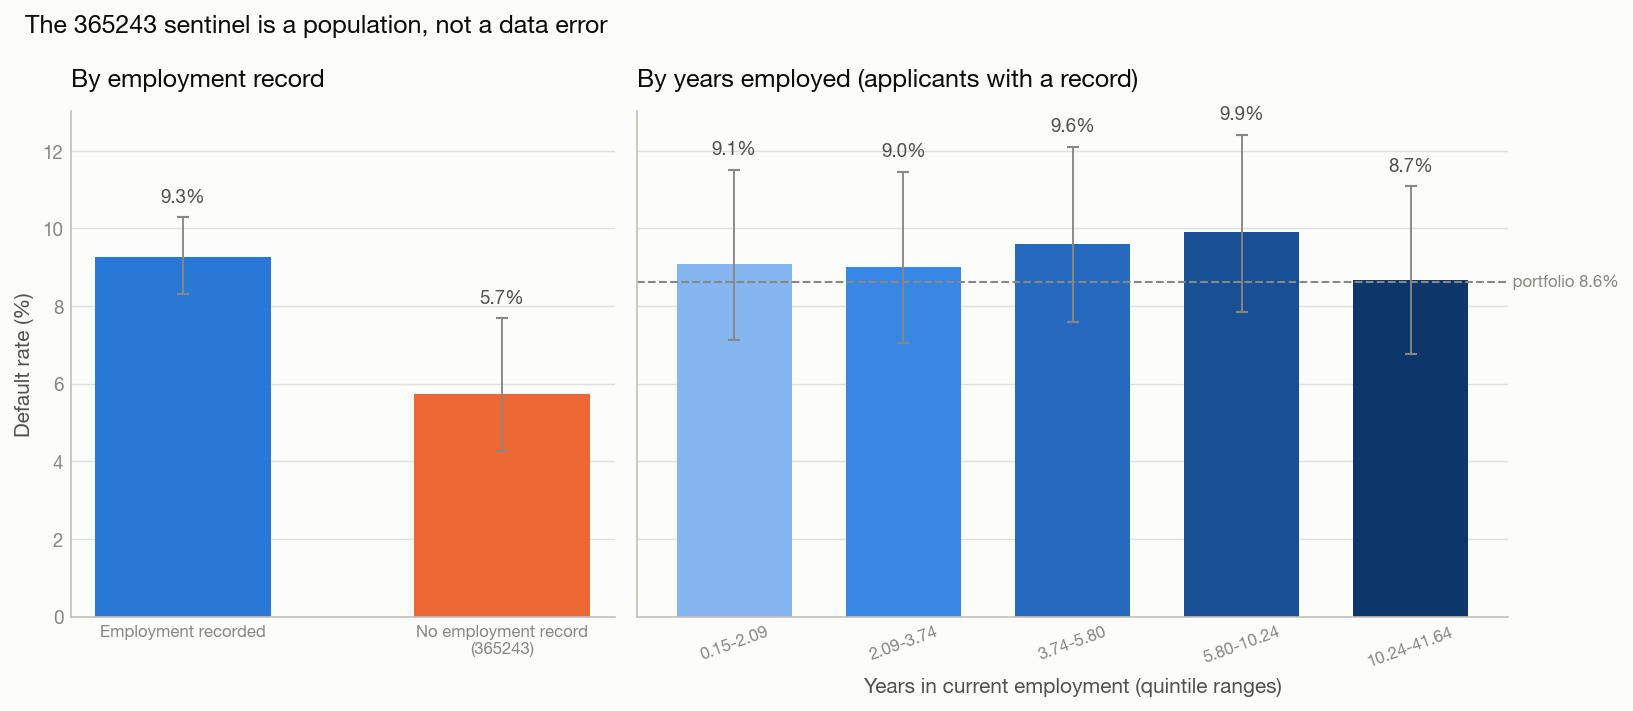

18% of applicants carry DAYS_EMPLOYED = 365243, which is not 1000 years of work but a sentinel for 'no employment record' -- and it maps almost perfectly onto pensioners. That group defaults at 5.7%, against 9.3% for applicants with a recorded job. Among applicants who do have a record, tenure length barely moves the default rate at all -- every band overlaps the portfolio average. The signal is in *whether* employment is recorded, not how long it has lasted. Left untreated the sentinel would dominate every tree split and destroy any coefficient on tenure, so it is nulled and replaced with an explicit flag. Practical use: pensioners need their own scorecard treatment -- their risk is driven by pension stability, not job tenure.


In [12]:
anomaly = eda.insight_employment_anomaly(df)
display(Image(str(anomaly.figure_path)))
print(anomaly.takeaway)

In [13]:
# The sentinel is not scattered at random -- it identifies a specific population.
pd.crosstab(
    df["NAME_INCOME_TYPE"],
    df["DAYS_EMPLOYED"] == 365243,
    rownames=["income type"], colnames=["has 365243 sentinel"],
)

has 365243 sentinel,False,True
income type,,
Businessman,2,0
Commercial associate,953,0
Maternity leave,2,0
Pensioner,0,711
State servant,285,0
Student,1,0
Unemployed,0,3
Working,2043,0


## 4. Business insights

Six findings a credit analyst could act on. Each rate carries a 95% Wilson confidence
interval — on segments this size a naive bar chart invites over-reading, so the
uncertainty is drawn, and the written takeaway hedges whenever the intervals overlap.

### 4.1 External credit scores dominate default risk

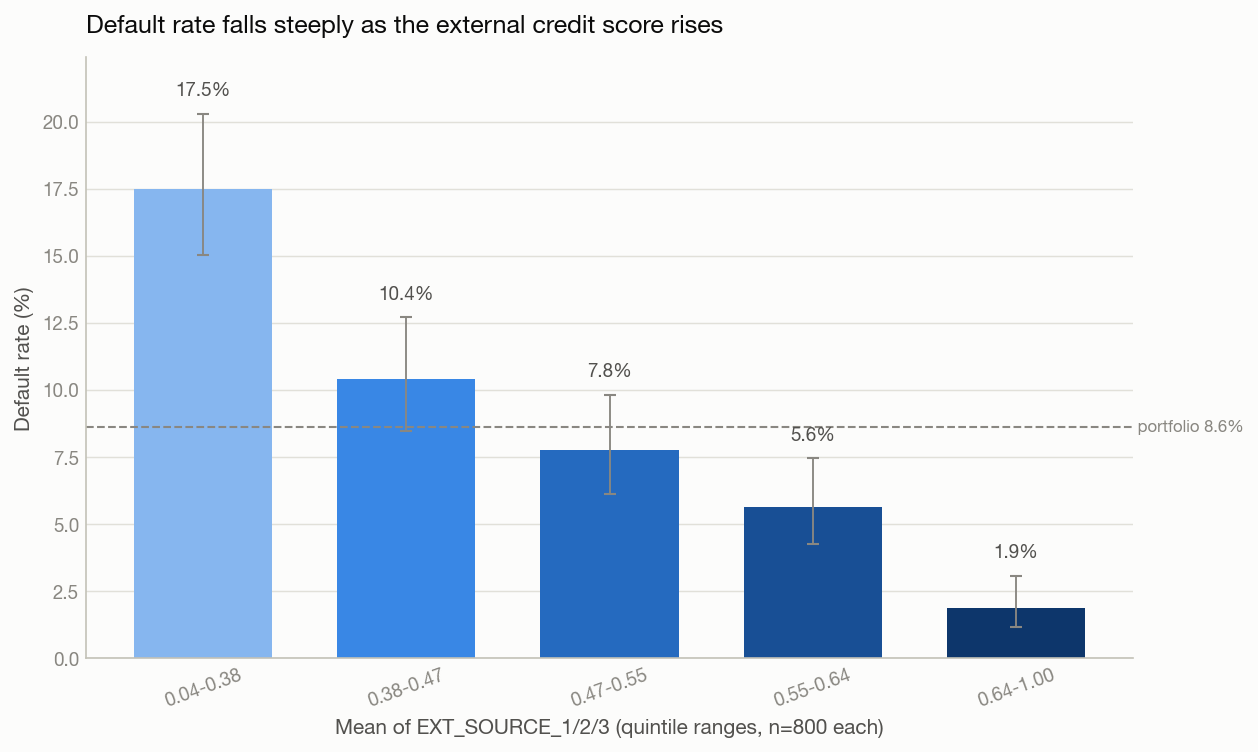

Applicants in the lowest external-score band default at 17.5%, versus 1.9% in the highest -- a 9.3x spread across an evenly-sized split of the book, and the decline is monotonic across every band, which is what makes it trustworthy for policy. This is the strongest single signal available. Practical use: the bottom band warrants manual review or a pricing uplift, and an applicant missing all three external scores should be routed to manual assessment rather than scored on the remaining fields.


,segment,n,n_default,default_rate,ci_low,ci_high
0,0.04-0.38,800,140,17.500000,15.02,20.29
1,0.38-0.47,799,83,10.387985,8.46,12.70
2,0.47-0.55,799,62,7.759700,6.10,9.82
3,0.55-0.64,799,45,5.632040,4.24,7.45
4,0.64-1.00,800,15,1.875000,1.14,3.07


In [14]:
ext = eda.insight_external_scores(df)
display(Image(str(ext.figure_path)))
print(ext.takeaway)
ext.table

### 4.2 Affordability ratios beat raw amounts

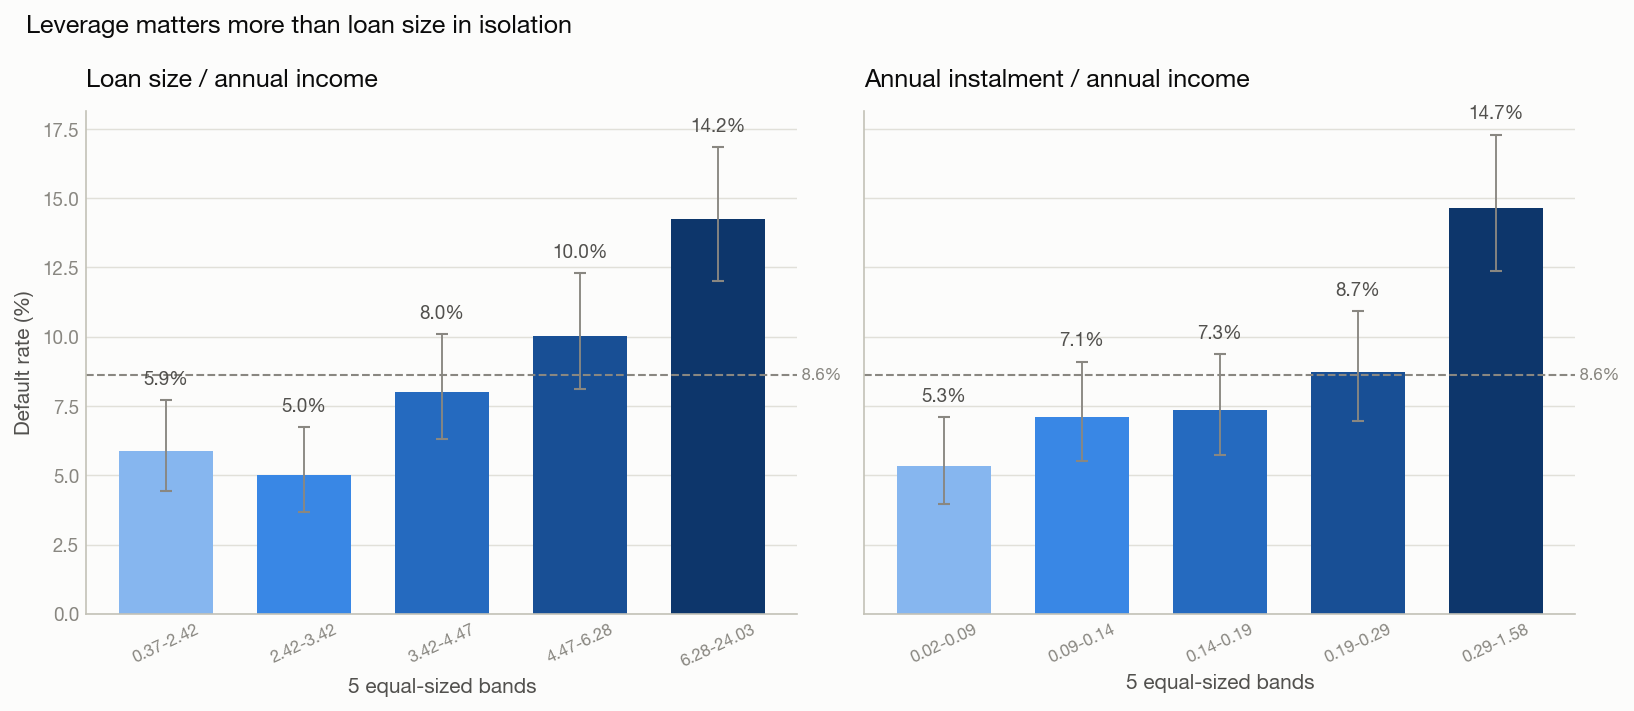

Default rate moves +8.4 percentage points from the least to the most leveraged quintile of loan-to-income. The absolute loan amount is a poor risk indicator on its own -- what matters is the amount relative to what the applicant earns. Practical use: cap loan-to-income at the point where the rate crosses the portfolio average rather than applying one flat maximum loan size, and treat a high instalment-to-income ratio as the affordability constraint at origination.


,metric,segment,n,n_default,default_rate,ci_low,ci_high
0,credit_to_income,0.37-2.42,802,47,5.860349,4.44,7.71
1,credit_to_income,2.42-3.42,800,40,5.000000,3.69,6.74
2,credit_to_income,3.42-4.47,799,64,8.010013,6.32,10.10
3,credit_to_income,4.47-6.28,799,80,10.012516,8.12,12.29
4,credit_to_income,6.28-24.03,800,114,14.250000,12.00,16.84
5,annuity_to_income,0.02-0.09,808,43,5.321782,3.97,7.09
6,annuity_to_income,0.09-0.14,789,56,7.097592,5.51,9.10
7,annuity_to_income,0.14-0.19,803,59,7.347447,5.74,9.36
8,annuity_to_income,0.19-0.29,789,69,8.745247,6.97,10.92
9,annuity_to_income,0.29-1.58,798,117,14.661654,12.38,17.29


In [15]:
afford = eda.insight_affordability(df)
display(Image(str(afford.figure_path)))
print(afford.takeaway)
afford.table

### 4.3 Customer attributes give stable policy segments

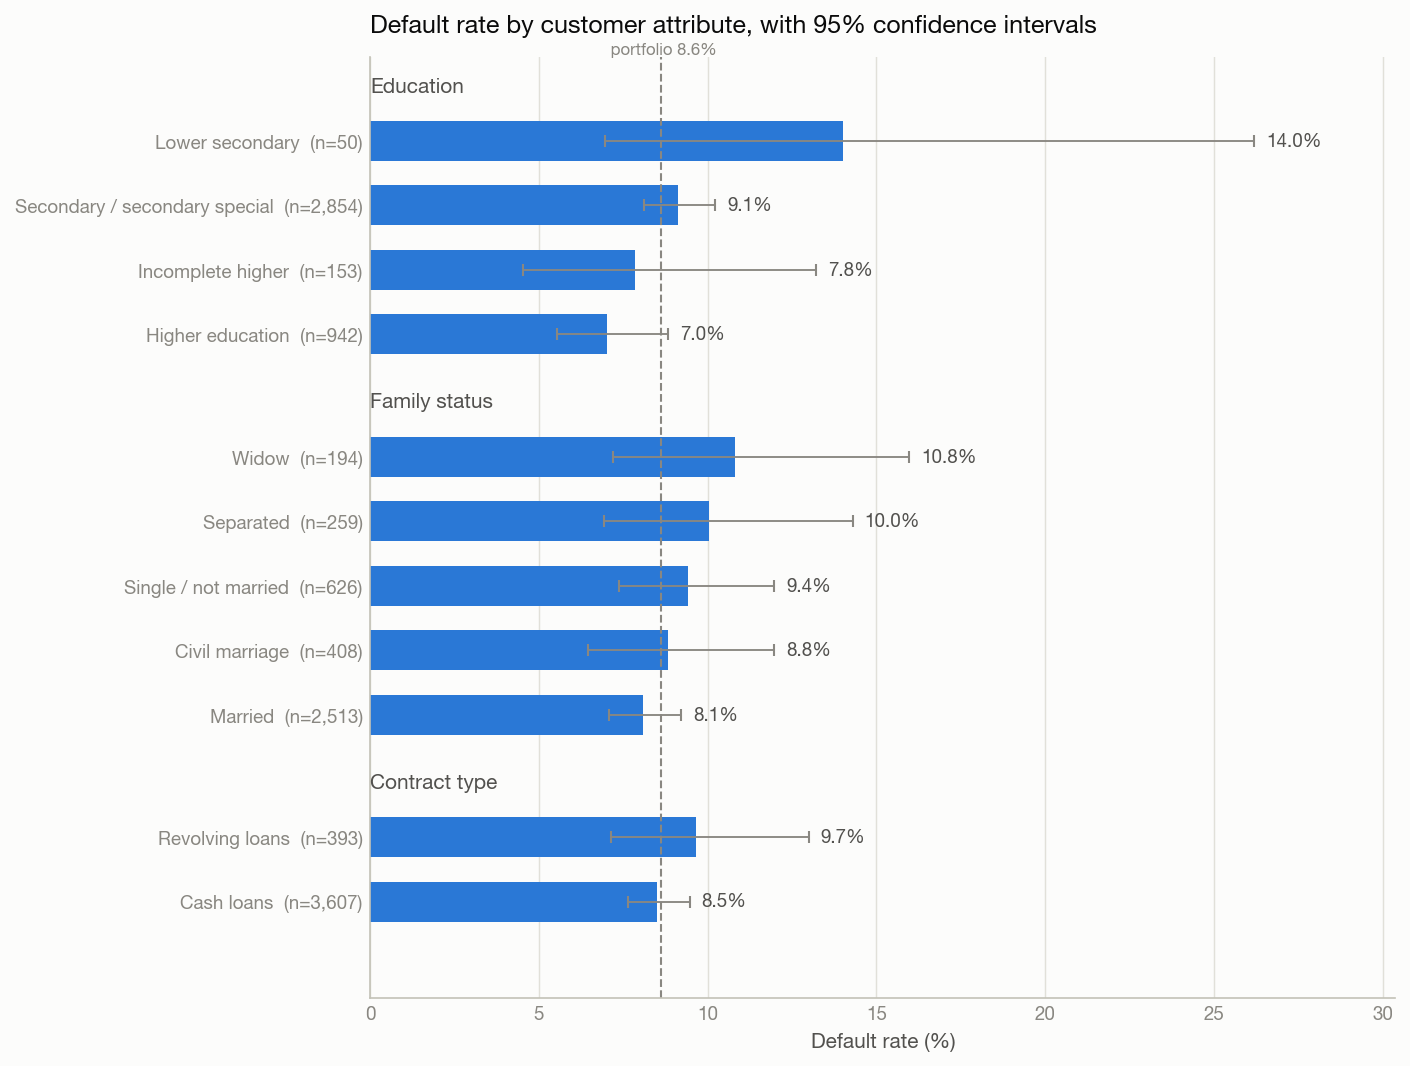

Education spreads default risk from 7.0% (Higher education, n=942) to 14.0% (Lower secondary, n=50). Their confidence intervals overlap, so treat this as directional only. Family status and contract type separate less sharply. Practical use: these are stable, verifiable attributes suited to policy segmentation -- but each is a proxy for income stability rather than a cause of default, so they belong in pricing tiers and review triggers, not hard decline rules, and must be checked against fair-lending constraints before any use in a decision.


,attribute,segment,n,n_default,default_rate,ci_low,ci_high
0,NAME_EDUCATION_TYPE,Lower secondary,50,7,14.000000,6.95,26.19
1,NAME_EDUCATION_TYPE,Secondary / secondary special,2854,260,9.110021,8.11,10.22
2,NAME_EDUCATION_TYPE,Incomplete higher,153,12,7.843137,4.54,13.21
3,NAME_EDUCATION_TYPE,Higher education,942,66,7.006369,5.54,8.82
4,NAME_FAMILY_STATUS,Widow,194,21,10.824742,7.19,15.98
5,NAME_FAMILY_STATUS,Separated,259,26,10.038610,6.94,14.30
6,NAME_FAMILY_STATUS,Single / not married,626,59,9.424920,7.38,11.97
7,NAME_FAMILY_STATUS,Civil marriage,408,36,8.823529,6.44,11.97
8,NAME_FAMILY_STATUS,Married,2513,203,8.077994,7.08,9.21
9,NAME_CONTRACT_TYPE,Revolving loans,393,38,9.669211,7.13,12.99


In [16]:
segments = eda.insight_demographic_segments(df)
display(Image(str(segments.figure_path)))
print(segments.takeaway)
segments.table

### 4.4 External credit history is the most actionable signal

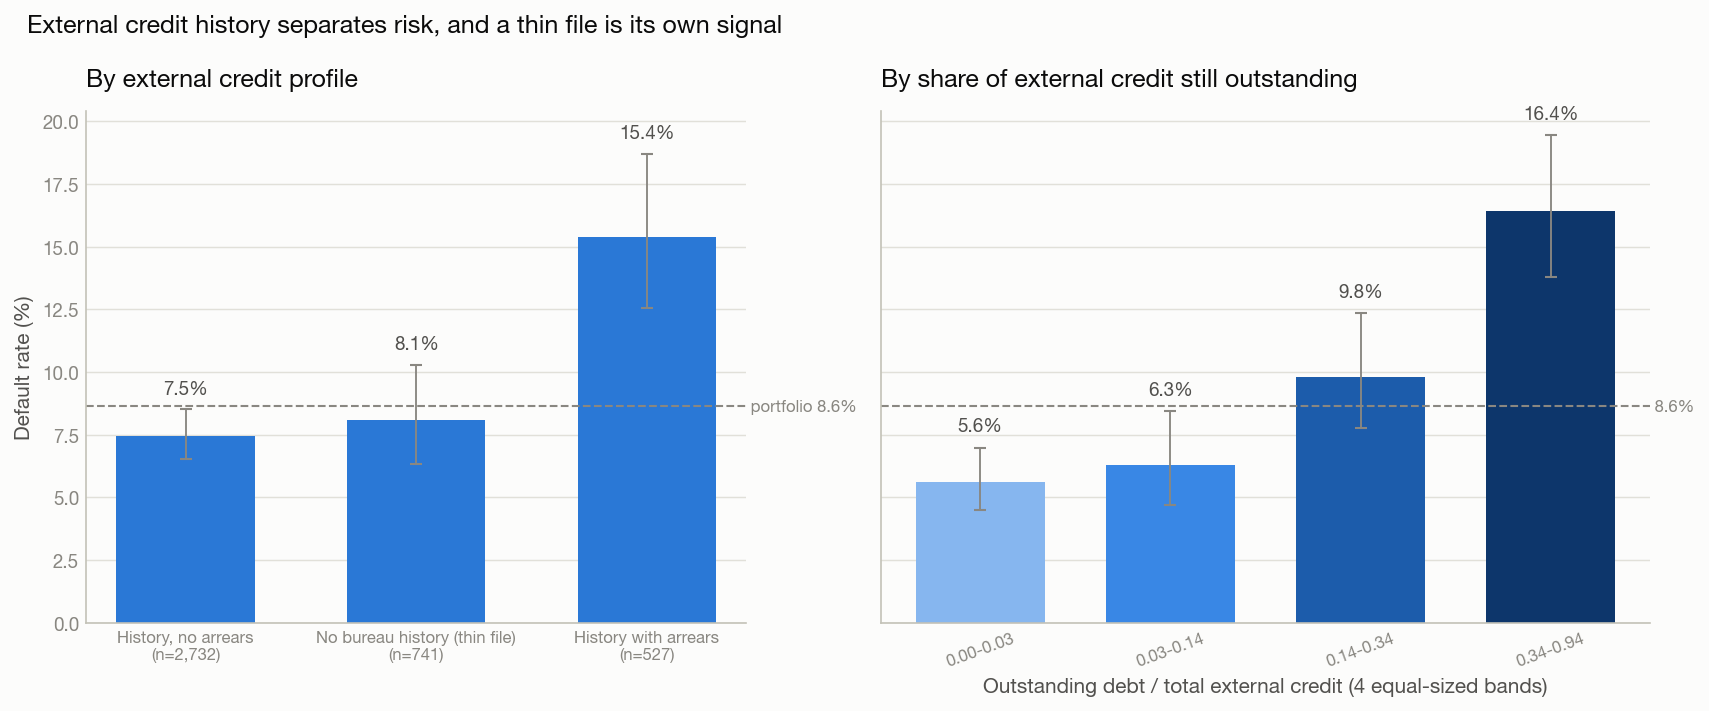

Applicants with prior arrears default at 15.4% -- 2.1x the rate of a clean external record, with non-overlapping confidence intervals (7.5%). Outstanding leverage tells the same story: the default rate climbs steadily with the share of external credit still unpaid. Thin-file applicants, with no bureau record at all, sit at 8.1%, which is why their nulls are preserved and flagged rather than imputed -- 'no history' is a distinct risk state, not a missing value to fill in. Practical use: prior arrears is the most defensible decline or referral trigger in the feature set, because it is behavioural rather than demographic and is externally verifiable.


,segment,n,n_default,default_rate,ci_low,ci_high,view
0,"History, no arrears",2732,204,7.467057,6.54,8.51,profile
1,No bureau history (thin file),741,60,8.097166,6.34,10.28,profile
2,History with arrears,527,81,15.370019,12.54,18.70,profile
3,0.00-0.03,1304,73,5.598160,4.48,6.98,debt_ratio
4,0.03-0.14,651,41,6.298003,4.68,8.43,debt_ratio
5,0.14-0.34,652,64,9.815951,7.76,12.34,debt_ratio
6,0.34-0.94,652,107,16.411043,13.77,19.45,debt_ratio


In [17]:
history = eda.insight_credit_history(df)
display(Image(str(history.figure_path)))
print(history.takeaway)
history.table

## 5. What this means for the model

The EDA drives five concrete choices in the modelling layer:

1. **Lead with PR-AUC.** At an ~8.6% positive rate, ROC-AUC flatters every model and
   accuracy is meaningless. PR-AUC is the honest headline.
2. **Weight the positive class; do not synthesise it.** `scale_pos_weight` preserves the
   true class prior, so the predicted probabilities stay calibratable. SMOTE would
   inflate the minority class and bias probabilities upward — unacceptable when the
   score itself is the product.
3. **Keep missingness; do not impute it away.** Missing is informative here — a thin
   bureau file and an undisclosed occupation are both risk signals. Tree models branch
   on NaN natively; only the linear baseline imputes, inside its own CV fold.
4. **Engineer ratios, not amounts.** Credit-to-income and annuity-to-income separate risk
   where absolute loan size does not, and they are what a credit officer already reasons
   about — so the model's explanations land in familiar language.
5. **Treat the employment sentinel as a feature.** Nulled and flagged, it becomes a clean
   pensioner indicator instead of an outlier that corrupts every split.

Full analysis, including the machine-readable insight index, is written to `reports/`
by `python -m notebooks.eda`.

In [18]:
report = eda.run_eda(df)
report.insight_index()

2026-09-06 08:16:07 | INFO     | notebooks.eda | Dataset: 4,000 rows x 147 cols | default rate 8.62% | imbalance 10.6:1


2026-09-06 08:16:07 | INFO     | notebooks.eda | Feature catalog: {'numeric': 88, 'binary': 36, 'categorical': 16, 'date_like': 5, 'identifier': 1, 'target': 1}


2026-09-06 08:16:07 | INFO     | notebooks.eda | Data quality: 5 findings


2026-09-06 08:16:07 | INFO     | notebooks.eda | Feature catalog: {'numeric': 88, 'binary': 36, 'categorical': 16, 'date_like': 5, 'identifier': 1, 'target': 1}


2026-09-06 08:16:08 | INFO     | notebooks.eda | EDA artifacts written to /Users/neeeha_k/credit_risk_platform/reports


,key,title,takeaway,figure
0,class_imbalance,"Defaults are rare, so the metric must be chose...","Only 8.6% of applicants default, a 11:1 imbala...",01_class_imbalance.png
1,missing_data,"Missing data is structural, not random","6 columns are more than half empty, led by OWN...",02_missing_data.png
2,feature_landscape,The portfolio's feature landscape,"The 147 columns split into 88 numeric, 16 cate...",03_feature_landscape.png
3,external_scores,External credit scores dominate default risk,Applicants in the lowest external-score band d...,04_external_scores.png
4,affordability,Affordability ratios separate risk better than...,Default rate moves +8.4 percentage points from...,05_affordability.png
5,employment_anomaly,The employment anomaly encodes a real population,18% of applicants carry DAYS_EMPLOYED = 365243...,06_employment_anomaly.png
6,demographic_segments,Customer attributes give stable policy segments,Education spreads default risk from 7.0% (High...,07_demographic_segments.png
7,credit_history,External credit history is the most actionable...,Applicants with prior arrears default at 15.4%...,08_credit_history.png
